# Instance Hardness Threshold undersampling on the hard / imbalanced datasets

Extends the IHT analysis (notebook 08) to the datasets added in functions.hard_data
and functions.imbalanced_data. IHT removes the majority-class instances a
cross-validated classifier scores as 'hard' (predicted P(class=1) above a
threshold). We sweep thresholds 0.3-0.7 and ask whether undersampling this way
improves a normal ensemble, evaluated at the optimal threshold.

Because IHT does not balance -- it only drops the hard majority points -- a high
threshold removes very little (on the hard datasets the classifier rarely scores
a majority point above 0.7), while a low threshold removes more.

**Full-data version.** This branch runs every dataset on its full data, including
the full 284,807-row creditcard set (see the dedicated section below). It is kept
separate from the merged work because the shared loader change would otherwise
alter notebooks 06/07, which use the 20k creditcard subsample.

In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.analysis import create_df, best_performance_summary
from functions.plotting import compute_ylim

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)

## Load results

Merge the plain-ensemble baselines with the five IHT thresholds.

In [3]:
scores_dict = {}
for path in ['../models/ensembles-hard/results', '../models/ensembles-imbalanced/results']:
    with open(path, 'rb') as f:
        for ds, d in pickle.load(f).items():
            scores_dict.setdefault(ds, {}).update(d)
for v in ['iht03', 'iht04', 'iht05', 'iht06', 'iht07']:
    with open(f'../models/iht-new/results_{v}', 'rb') as f:
        for ds, d in pickle.load(f).items():
            scores_dict.setdefault(ds, {}).update(d)

datasets = [d for d in ['htru2', 'default_credit', 'diabetes130', 'secom', 'creditcard']
            if any('_iht' in k for k in scores_dict.get(d, {}))]
plain_models = ['rf', 'ada', 'gbm', 'cat', 'lgbm', 'xgb']
{ds: len(scores_dict[ds]) for ds in datasets}

{'htru2': 36, 'default_credit': 36, 'diabetes130': 36, 'secom': 36}

## How much does each threshold remove?

IHT removes the majority points scored as hard (P(class=1) > threshold), so a
lower threshold removes more. On the harder, less-separable datasets the
classifier scores more majority points as hard, so more get removed.

In [4]:
with open('../models/iht-new/sampling_stats', 'rb') as f:
    sampling_stats = pickle.load(f)
rows = []
for version, per in sampling_stats.items():
    for ds, st in per.items():
        rows.append({'threshold': version, 'dataset': ds, 'removed_pct': st['removed_pct']})
removal = pd.DataFrame(rows).pivot(index='threshold', columns='dataset', values='removed_pct')
removal = removal[[d for d in datasets if d in removal.columns]]
removal

dataset,htru2,default_credit,diabetes130,secom
threshold,,,,
iht03,1.1,12.2,1.5,1.7
iht04,0.8,7.1,0.3,0.2
iht05,0.6,4.6,0.0,0.0
iht06,0.4,2.5,0.0,0.0
iht07,0.3,1.1,0.0,0.0


## Performance per metric

Per dataset: plain ensembles plus every IHT-undersampled ensemble (6 models x 5
thresholds). The pink band is the random forest (no resampling) reference; a
method helps only if it sits clearly above it. All threshold-based metrics are
at their optimal threshold.

In [5]:
def plot_metric(metric, std_metric, title, fname):
    fig, axes = plt.subplots(len(datasets), 1, figsize=(18, 4 * len(datasets)))
    for ax, data in zip(axes, datasets):
        models = list(scores_dict[data].keys())
        df = create_df(scores_dict, data, models)
        means, stds = df[metric], df[std_metric]
        upper = df.loc['rf', metric] + df.loc['rf', std_metric]
        lower = df.loc['rf', metric] - df.loc['rf', std_metric]
        colors = ['tab:blue' if m in plain_models else 'tab:purple' for m in df.index]
        ax.errorbar(x=df.index, y=means, yerr=stds, fmt='none', ecolor='gray', capsize=3, zorder=1)
        ax.scatter(df.index, means, c=colors, s=40, zorder=2)
        ax.set_title(data, fontsize=13)
        ax.set_ylim(compute_ylim(means, stds, upper, lower))
        ax.tick_params(axis='x', rotation=90, labelsize=6)
        ax.grid(True, alpha=0.3)
        ax.axhline(upper, color='r', ls='--', alpha=0.5)
        ax.axhline(lower, color='r', ls='--', alpha=0.5)
        ax.axhspan(lower, upper, facecolor='pink', alpha=0.3)
    plt.suptitle(title, fontsize=15, y=1.005)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

# blue = plain ensembles, purple = IHT-undersampled; pink band = RF +/- std

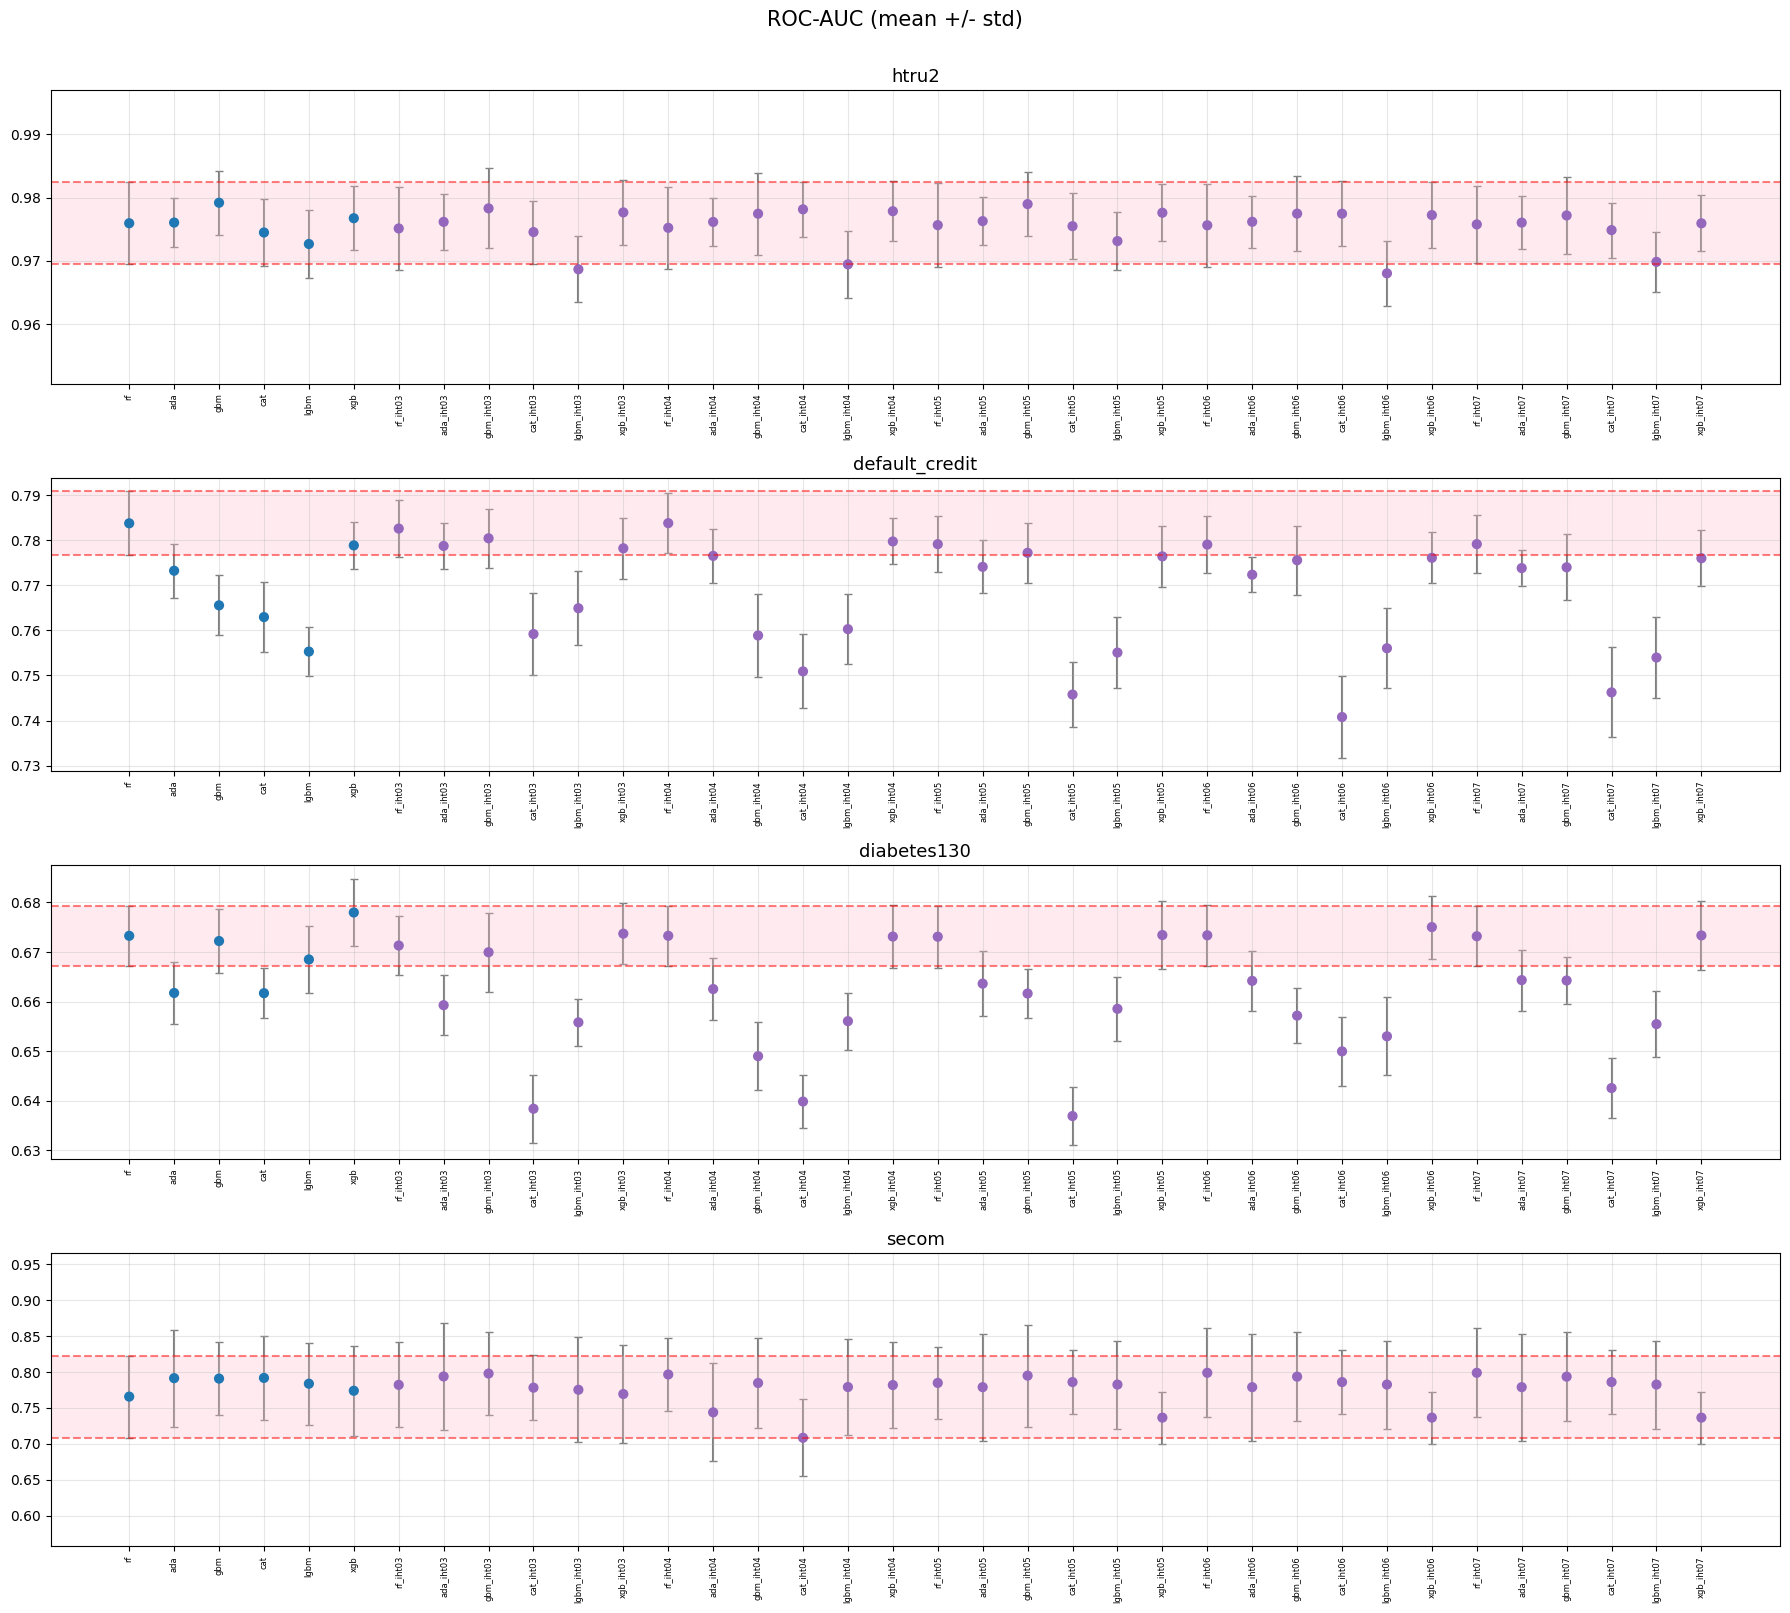

In [6]:
plot_metric('roc', 'roc_std', 'ROC-AUC (mean +/- std)', '../figures/iht-new_rocauc.png')

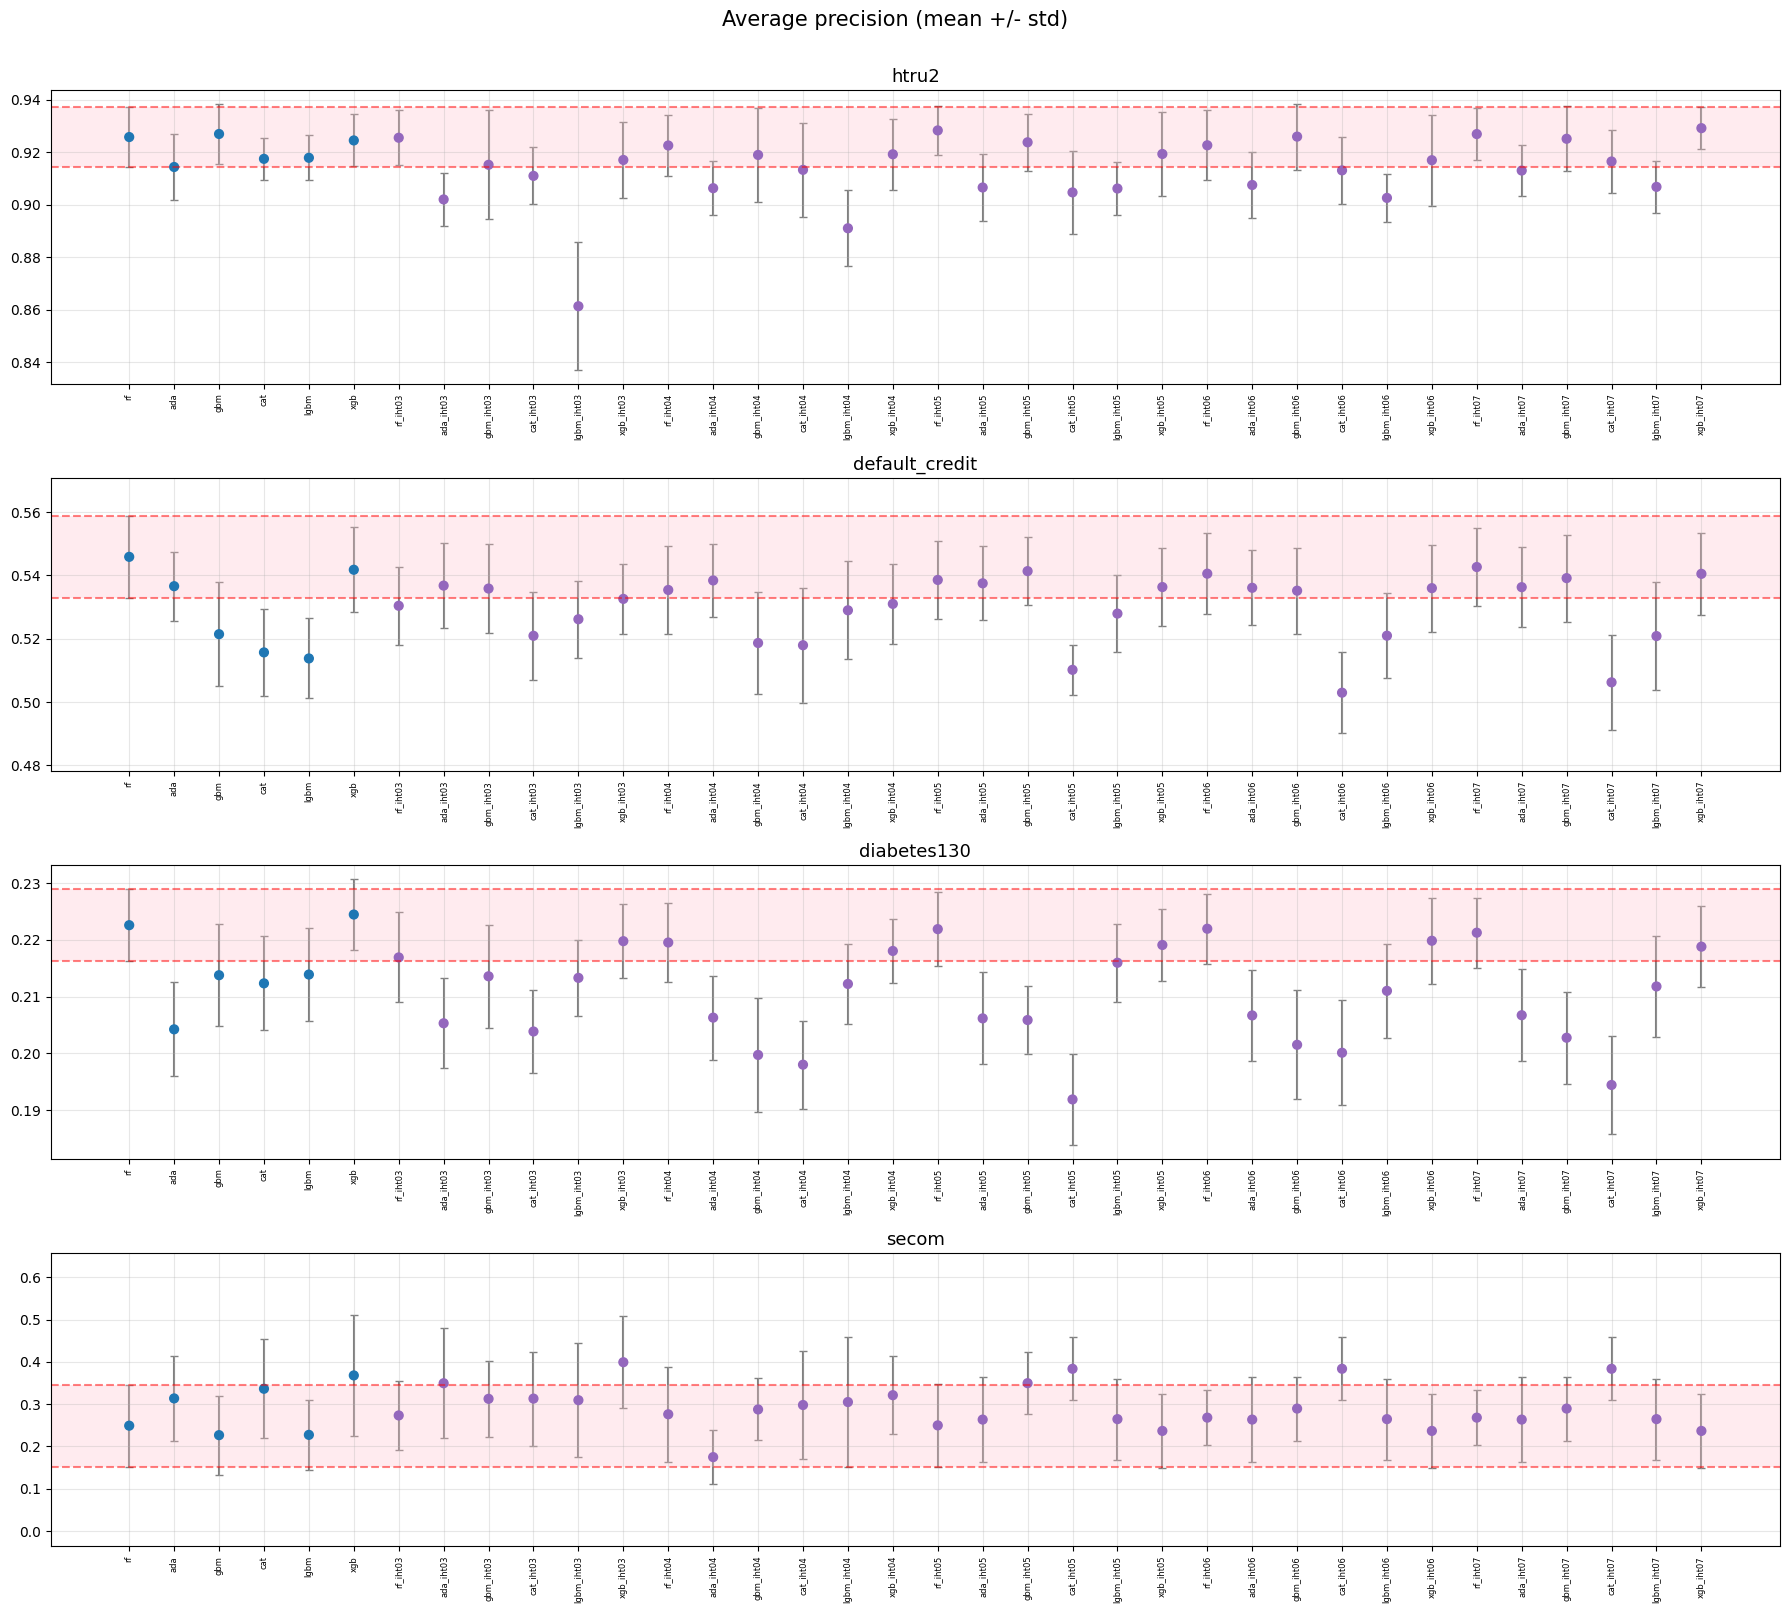

In [7]:
plot_metric('ap', 'ap_std', 'Average precision (mean +/- std)', '../figures/iht-new_ap.png')

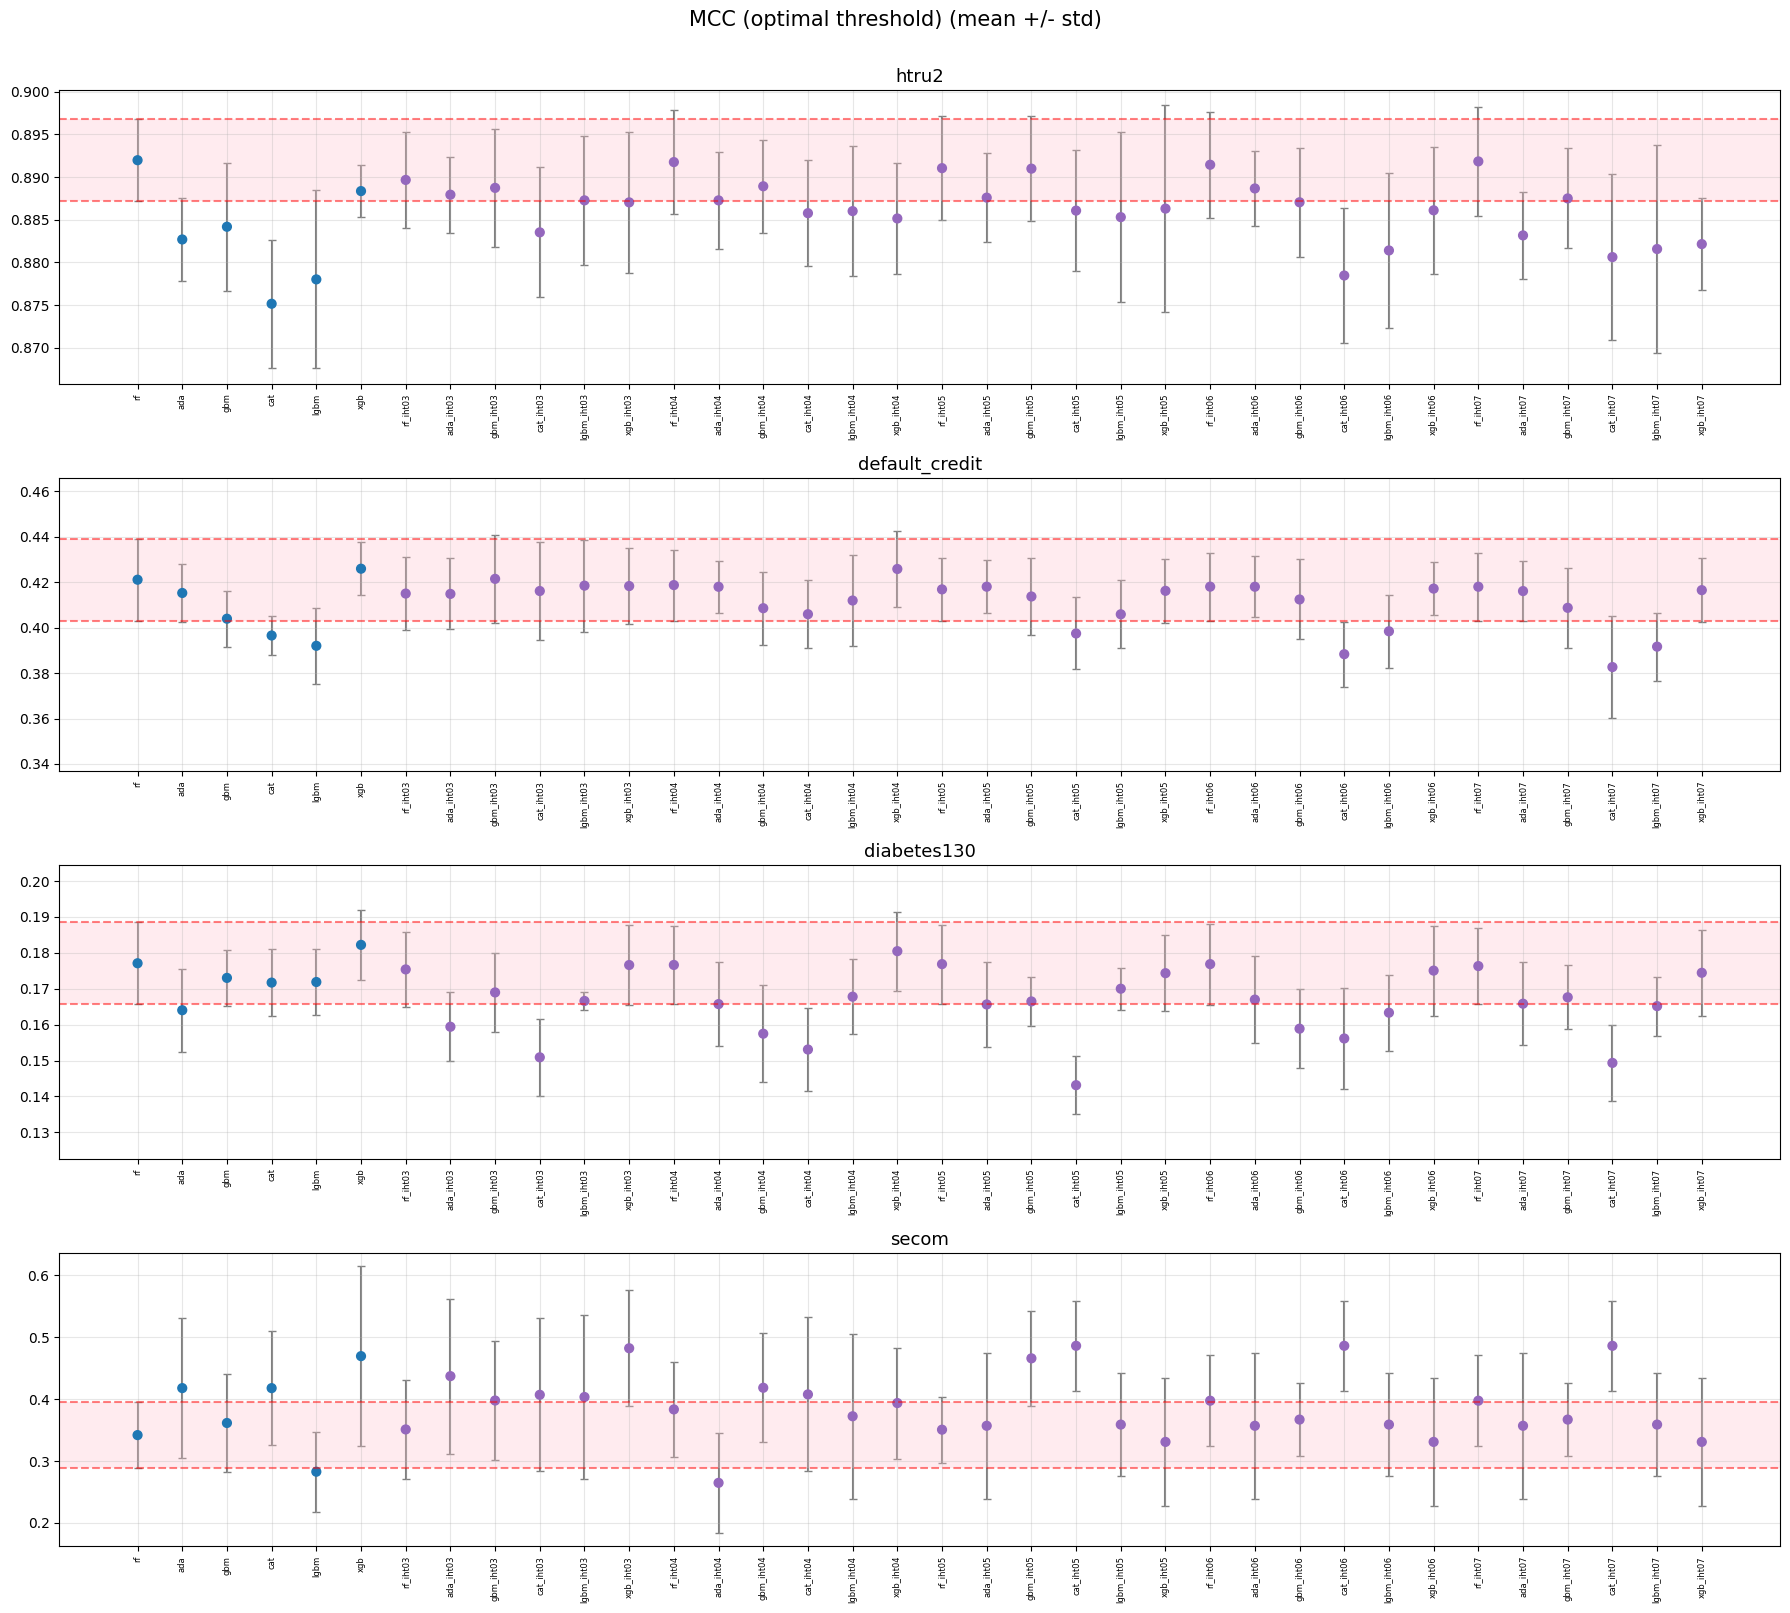

In [8]:
plot_metric('mcc', 'mcc_std', 'MCC (optimal threshold) (mean +/- std)', '../figures/iht-new_mcc.png')

## Best IHT variant per model (significance-highlighted)

Using the project's `best_performance_summary`: for each base model it picks the
best IHT threshold and flags whether the gain exceeds 1x (green) or 3x (red) the
standard deviation.

In [9]:
best_performance_summary(scores_dict, datasets, metric='roc', metric_std='roc_std')

,dataset,model,roc,roc_std,best_csl_variant,best_csl_roc,best_csl_roc_std,roc_diff
0,htru2,rf,0.975950,0.006487,rf_iht07,0.975767,0.006137,-0.000183
1,htru2,ada,0.976055,0.003916,ada_iht05,0.976284,0.003835,0.000229
2,htru2,gbm,0.979190,0.005084,gbm_iht05,0.978973,0.005028,-0.000217
3,htru2,cat,0.974489,0.005279,cat_iht04,0.978148,0.004364,0.003659
4,htru2,lgbm,0.972672,0.005391,lgbm_iht05,0.973132,0.004562,0.000460
5,htru2,xgb,0.976745,0.005060,xgb_iht04,0.977852,0.004756,0.001107
6,default_credit,rf,0.783773,0.007131,rf_iht04,0.783810,0.006645,0.000037
7,default_credit,ada,0.773246,0.005951,ada_iht03,0.778747,0.005107,0.005502
8,default_credit,gbm,0.765565,0.006663,gbm_iht03,0.780443,0.006511,0.014878
9,default_credit,cat,0.762962,0.007821,cat_iht03,0.759202,0.009094,-0.003760


In [10]:
best_performance_summary(scores_dict, datasets, metric='ap', metric_std='ap_std')

,dataset,model,ap,ap_std,best_csl_variant,best_csl_ap,best_csl_ap_std,ap_diff
0,htru2,rf,0.925760,0.011367,rf_iht05,0.928283,0.009299,0.002523
1,htru2,ada,0.914364,0.012717,ada_iht07,0.913009,0.009802,-0.001355
2,htru2,gbm,0.926928,0.011477,gbm_iht06,0.925925,0.012534,-0.001003
3,htru2,cat,0.917470,0.008102,cat_iht07,0.916463,0.011995,-0.001007
4,htru2,lgbm,0.917869,0.008510,lgbm_iht07,0.906808,0.009858,-0.011061
5,htru2,xgb,0.924473,0.009883,xgb_iht07,0.929144,0.007995,0.004671
6,default_credit,rf,0.545877,0.012970,rf_iht07,0.542662,0.012213,-0.003215
7,default_credit,ada,0.536611,0.010863,ada_iht04,0.538426,0.011406,0.001815
8,default_credit,gbm,0.521453,0.016386,gbm_iht05,0.541364,0.010689,0.019912
9,default_credit,cat,0.515697,0.013742,cat_iht03,0.520942,0.013863,0.005246


In [11]:
best_performance_summary(scores_dict, datasets, metric='mcc', metric_std='mcc_std')

,dataset,model,mcc,mcc_std,best_csl_variant,best_csl_mcc,best_csl_mcc_std,mcc_diff
0,htru2,rf,0.891981,0.004815,rf_iht07,0.891841,0.006363,-0.000139
1,htru2,ada,0.882686,0.004920,ada_iht06,0.888668,0.004447,0.005982
2,htru2,gbm,0.884175,0.007481,gbm_iht05,0.890991,0.006172,0.006815
3,htru2,cat,0.875146,0.007530,cat_iht05,0.886070,0.007100,0.010923
4,htru2,lgbm,0.878004,0.010449,lgbm_iht03,0.887271,0.007548,0.009267
5,htru2,xgb,0.888359,0.003059,xgb_iht03,0.887037,0.008292,-0.001322
6,default_credit,rf,0.421102,0.018077,rf_iht04,0.418738,0.015625,-0.002365
7,default_credit,ada,0.415263,0.012560,ada_iht05,0.418023,0.011685,0.002761
8,default_credit,gbm,0.403929,0.012281,gbm_iht03,0.421475,0.019265,0.017546
9,default_credit,cat,0.396537,0.008677,cat_iht03,0.416125,0.021406,0.019588


## Combined table

In [12]:
dfs = [create_df(scores_dict, d, list(scores_dict[d].keys())) for d in datasets]
result = pd.concat(dfs, keys=datasets, names=['dataset', 'model'])
result.to_csv('../results/iht-new_models_performance.csv')
result[['roc', 'ap', 'f1_score', 'mcc', 'ba', 'gmean']].round(3)

roc     ap  f1_score    mcc     ba  gmean
dataset model                                                  
htru2   rf          0.976  0.926     0.900  0.892  0.952  0.951
        ada         0.976  0.914     0.892  0.883  0.948  0.947
        gbm         0.979  0.927     0.893  0.884  0.949  0.949
        cat         0.974  0.917     0.884  0.875  0.943  0.942
        lgbm        0.973  0.918     0.887  0.878  0.944  0.944
...                   ...    ...       ...    ...    ...    ...
secom   ada_iht07   0.779  0.263     0.366  0.357  0.743  0.735
        gbm_iht07   0.794  0.289     0.399  0.367  0.759  0.750
        cat_iht07   0.786  0.384     0.464  0.486  0.745  0.736
        lgbm_iht07  0.783  0.265     0.377  0.359  0.750  0.740
        xgb_iht07   0.737  0.237     0.306  0.331  0.721  0.710

[144 rows x 6 columns]

## Does IHT beat the plain ensemble?

For each dataset and metric, best IHT-undersampled ensemble vs best plain
ensemble. Positive delta means IHT helped.

In [13]:
metric_cols = {'roc': 'roc', 'ap': 'ap', 'f1': 'f1_score', 'mcc': 'mcc',
               'ba': 'ba', 'gmean': 'gmean'}
rows = []
for ds in datasets:
    keys = list(scores_dict[ds].keys())
    iht = [k for k in keys if '_iht' in k]
    df = create_df(scores_dict, ds, keys)
    for short, col in metric_cols.items():
        best_plain = df.loc[plain_models, col].max()
        best_iht = df.loc[iht, col].max()
        rows.append({'dataset': ds, 'metric': short,
                     'best_plain': round(float(best_plain), 3),
                     'best_iht': round(float(best_iht), 3),
                     'best_iht_model': df.loc[iht, col].idxmax(),
                     'delta': round(float(best_iht - best_plain), 3)})
summary = pd.DataFrame(rows)
summary

,dataset,metric,best_plain,best_iht,best_iht_model,delta
0,htru2,roc,0.979,0.979,gbm_iht05,-0.000
1,htru2,ap,0.927,0.929,xgb_iht07,0.002
2,htru2,f1,0.900,0.900,rf_iht07,0.000
3,htru2,mcc,0.892,0.892,rf_iht07,-0.000
4,htru2,ba,0.952,0.953,gbm_iht04,0.002
5,htru2,gmean,0.951,0.953,gbm_iht04,0.002
6,default_credit,roc,0.784,0.784,rf_iht04,0.000
7,default_credit,ap,0.546,0.543,rf_iht07,-0.003
8,default_credit,f1,0.540,0.543,rf_iht05,0.002
9,default_credit,mcc,0.426,0.426,xgb_iht04,-0.000


In [14]:
wins = (summary['delta'] > 0).sum()
print(f'IHT beats best plain ensemble in {wins}/{len(summary)} (dataset, metric) cells')
print(f'Mean delta (best IHT - best plain): {summary.delta.mean():+.3f}')
summary.pivot(index='dataset', columns='metric', values='delta')[['roc','ap','f1','mcc','ba','gmean']]

IHT beats best plain ensemble in 10/24 (dataset, metric) cells
Mean delta (best IHT - best plain): +0.003


metric,roc,ap,f1,mcc,ba,gmean
dataset,,,,,,
default_credit,0.000,-0.003,0.002,-0.000,-0.002,-0.003
diabetes130,-0.003,-0.003,0.002,-0.002,-0.003,-0.002
htru2,-0.000,0.002,0.000,-0.000,0.002,0.002
secom,0.007,0.031,-0.004,0.017,0.016,0.020


## creditcard on the full data

creditcard is the severe case (0.17% positive). Here it is run on the **full**
284,807-row dataset (199,364 train / 85,443 test, 147 fraud) -- this is why this
notebook lives on a separate branch from the merged work, which keeps creditcard
subsampled so notebooks 06/07 stay consistent. There is no separate full-data
*plain* baseline to compare against, so we show IHT's removal and metrics
directly: at ~0% removal every model already **is** a plain full-data ensemble.

In [15]:
cc = pickle.load(open('../models/iht-new/results_creditcard_full', 'rb'))
cc_stats = pickle.load(open('../models/iht-new/sampling_stats', 'rb'))
iht_versions = ['iht03', 'iht04', 'iht05', 'iht06', 'iht07']
removal_cc = pd.DataFrame([
    {'threshold': v,
     'removed_rows': cc_stats[v]['creditcard']['removed'],
     'train_size': cc_stats[v]['creditcard']['original_size'],
     'removed_pct': round(cc_stats[v]['creditcard']['removed_pct'], 3)}
    for v in iht_versions]).set_index('threshold')
merged_cc = {k: val for v in iht_versions for k, val in cc[v].items()}
cc_df = create_df({'creditcard': merged_cc}, 'creditcard', list(merged_cc.keys()))
metrics_cc = pd.DataFrame([
    {'threshold': v,
     'best_roc': round(cc_df[cc_df.index.str.endswith(v)]['roc'].max(), 3),
     'best_ap': round(cc_df[cc_df.index.str.endswith(v)]['ap'].max(), 3),
     'best_mcc': round(cc_df[cc_df.index.str.endswith(v)]['mcc'].max(), 3)}
    for v in iht_versions]).set_index('threshold')
print('Removal on the full 199,364-row training set:')
display(removal_cc)
print('Best of the 6 ensembles per threshold (optimal-threshold metrics):')
display(metrics_cc)

Removal on the full 199,364-row training set:


,removed_rows,train_size,removed_pct
threshold,,,
iht03,39,199364,0.0
iht04,27,199364,0.0
iht05,18,199364,0.0
iht06,9,199364,0.0
iht07,5,199364,0.0


Best of the 6 ensembles per threshold (optimal-threshold metrics):


,best_roc,best_ap,best_mcc
threshold,,,
iht03,0.982,0.837,0.883
iht04,0.981,0.860,0.893
iht05,0.986,0.845,0.882
iht06,0.981,0.861,0.886
iht07,0.981,0.864,0.897


## Conclusion

**IHT barely undersamples these datasets, and where it does, it does not help.**

*How much it removes.* IHT drops the majority points a classifier scores as hard
(P(class=1) > threshold). On severely imbalanced data the classifier confidently
scores the majority as majority, so almost nothing crosses the threshold: removal
is ~0-1.7% on htru2 and diabetes130. The exception is default_credit (22%
positive, the least imbalanced), where it removes up to ~12% at threshold 0.3. So
removal tracks class balance, not separability.

*Does it help?* At the optimal threshold, no. The best IHT variant is tied with
or slightly below the best plain ensemble on htru2, default_credit and
diabetes130 -- including on default_credit, where dropping ~12% of the borderline
majority gives no gain (a direct test of the 'removing hard examples helps' claim
that does not hold here).

*The one lift: secom.* On the hardest, highest-dimensional dataset, IHT improves
average precision (+0.03) and MCC (+0.02) over the best plain ensemble, even
though it removes <2%. This matches the cleaning-undersampler result on secom
(notebook 07): on heavily-overlapping high-dimensional data, removing a few
hard/borderline majority points helps a little. secom's test set is small (~26
positives), so it is suggestive rather than conclusive.

This is consistent with the special-ensemble (05/06) and undersampling (07)
results: resampling does not beat a well-tuned standard ensemble at the optimal
threshold, with secom the lone (noisy) exception.

**creditcard (full data).** The section above runs IHT on the full 284,807-row
creditcard set (199,364 train, 85,443 test, 147 fraud) -- on this separate branch
because `main` keeps creditcard subsampled so notebooks 06/07 stay consistent. It
removes
essentially nothing at every threshold (5 to 39 rows of 199k, ~0.00%), because at
0.17% positive the classifier scores almost no majority point as hard. So every
'IHT' model is just a plain ensemble on the full data, and they all land in the
same place: ROC-AUC ~0.986, average precision ~0.864, MCC ~0.897 (those strong
scores reflect creditcard's learnable signal, not IHT). IHT has no effect here,
exactly as the ~0% removal predicts.
